In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
%reload_ext autoreload

In [3]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/mydata/cope/mirco/data/ssp585_time_series.pkl'

In [4]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

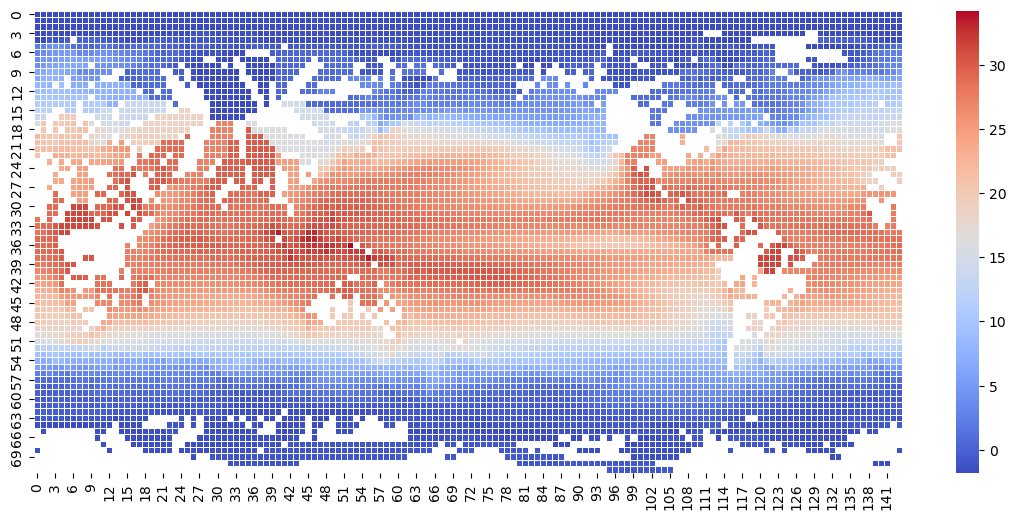

In [5]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

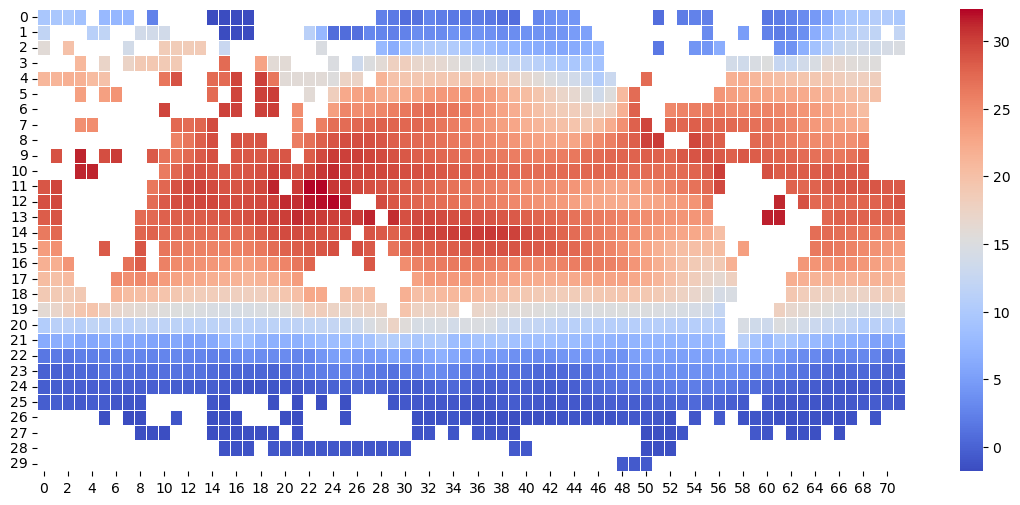

In [6]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

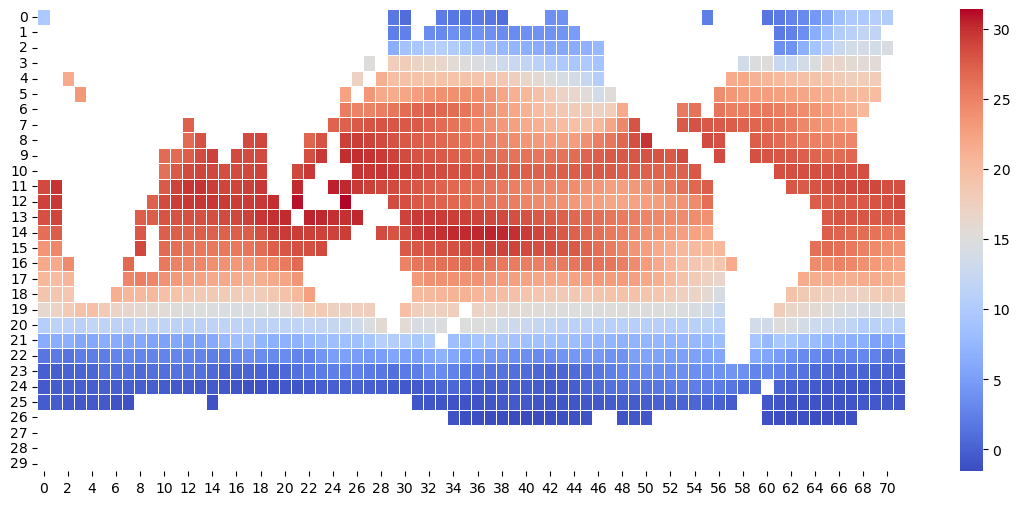

In [7]:
union_nan_mask = find_union_nan_mask(cope_data)
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [8]:
X, Y = extract_per_timeserie(cope_data, union_nan_mask, r=[-10, 10])
print(X.shape, Y.shape)

(612, 44472) (612, 44472)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [10]:
batch_size = 16

cope_dataset = CopeDataset(samples=X, labels=Y)

train_dataset, test_dataset = random_split(cope_dataset, [0.8, 0.2])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
lr = 2e-3
epochs = 30

model = basic_VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


print("Start training basic VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, logvar = model(x)
        loss = model.loss(x_hat, y, mean, logvar)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training basic VAE...
Epoch 1 complete ! 	Average Loss:  651079.4839311079
Epoch 2 complete ! 	Average Loss:  10457.421564275568
Epoch 3 complete ! 	Average Loss:  9399.67616595644
Epoch 4 complete ! 	Average Loss:  8665.444557883522
Epoch 5 complete ! 	Average Loss:  8405.162560665247
Epoch 6 complete ! 	Average Loss:  8263.899569424715
Epoch 7 complete ! 	Average Loss:  8146.199662642045
Epoch 8 complete ! 	Average Loss:  8276.578835227272
Epoch 9 complete ! 	Average Loss:  8035.678858901515
Epoch 10 complete ! 	Average Loss:  7969.940000591856
Epoch 11 complete ! 	Average Loss:  7927.364657315341
Epoch 12 complete ! 	Average Loss:  7919.544063683712
Epoch 13 complete ! 	Average Loss:  8557.808578953598
Epoch 14 complete ! 	Average Loss:  7976.912982362689
Epoch 15 complete ! 	Average Loss:  7755.454804391572
Epoch 16 complete ! 	Average Loss:  7654.18339399858
Epoch 17 complete ! 	Average Loss:  7646.499955610795
Epoch 18 complete ! 	Average Loss:  7546.279430042614
Epoch 19 c

In [13]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)

        break

In [11]:
lr = 2e-3
epochs = 30

model = VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
Epoch 1 complete ! 	Average Loss:  64595.84469401042
Epoch 2 complete ! 	Average Loss:  5750.912296549479


KeyboardInterrupt: 

In [18]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)
        x_hat.detach()

        break

In [19]:
print(x.shape)
print(x_hat.shape)
print(y.shape)

torch.Size([16, 44472])
torch.Size([16, 44472])
torch.Size([16, 44472])


In [20]:
x, x_hat, y = x.numpy(), x_hat.numpy(), y.numpy()

5.5768476 -4.752848


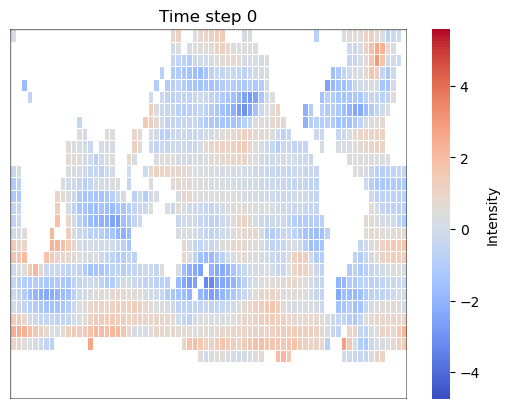

In [21]:
from plots import get_animated_timeserie

a = get_animated_timeserie(x[0], union_nan_mask)
a.save('x.gif', writer='pillow', fps=1)

C:\Users\mirco\AppData\Local\Temp\ipykernel_10744\1817344449.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_animated_timeserie(np.array(x_hat[0]), union_nan_mask)


2.3774114 -2.0995712


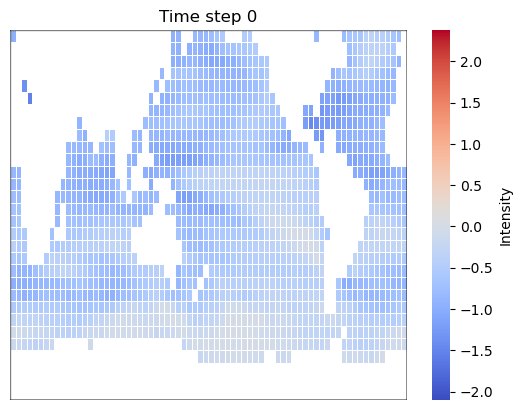

In [37]:
from plots import get_animated_timeserie

a = get_animated_timeserie(x_hat[0], union_nan_mask)
a.save('x_hat.gif', writer='pillow', fps=1)

C:\Users\mirco\AppData\Local\Temp\ipykernel_10744\3833773037.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_animated_timeserie(np.array(y[0]), union_nan_mask)


2.6262555 -2.6271024


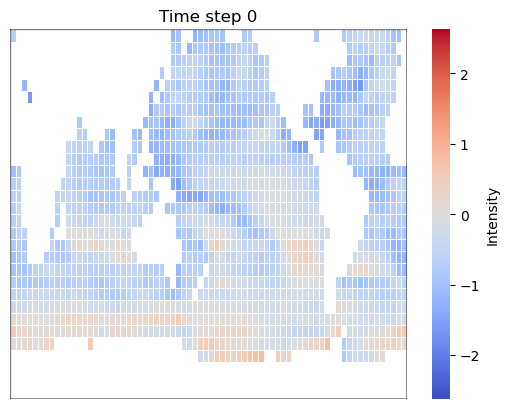

In [38]:
from plots import get_animated_timeserie

a = get_animated_timeserie(y[0], union_nan_mask)
a.save('y.gif', writer='pillow', fps=1)

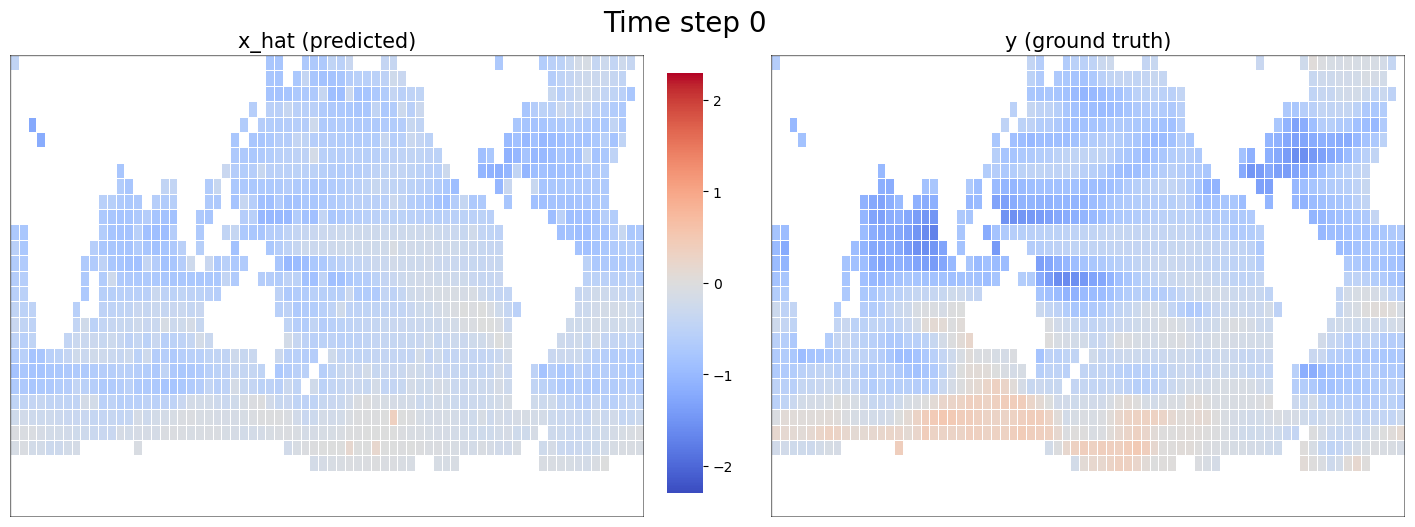

In [ ]:
from plots import get_duo_animated_timeserie

a = get_duo_animated_timeserie(x_hat[0], y[0], union_nan_mask)
a.save('compare_pred_and_truth.gif', writer='pillow', fps=1)

In [19]:
import os
os.environ['PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT']='2'

In [ ]:
"""
1)
pour normalisation, standardiser aussi avec le temps (run + temps et pas seulement run) - DONE
pour normaliser le test set, tu centre en temps (sur le test set data (a chaque run tu enleves sa moyenne))) - DONE
Normalized MSE (Standardized) -> tu divises par la variance du test set - DONE
-> rerun training  - DONE

2)
Créer un LOOCV pour le VAE (en utilisant le même principe que le ridge) - DONE
jouer un peu avec les paramtètres du VAE (lr, etc...) -> voir quand tu fais du sampling des variables latent, quelle est la tête des timeseries -> créer une animation (matplotlib animation FuncAnimation) - DONE
Faire un CVAE

pour plus tard : pouvoir faire un confidence interval en samplant par ex. 10 images avec le decoder pour voir la performance du modèle
                 investiguer le timeVAE
"""

In [ ]:
"""
Faire une comparaison de ridge, un tableau (ajouter le 95% et worst-case)
save the loss et pas les résultats - DONE
utiliser un ltsm ou réduire le size de l'input à l'avance avec des techniques de réduction de dimension
-> comment extraire une map de l'input qui explique le plus le forced response y -> convuler en espace pour le CVAE d'abord
NE PAS SENTIR BLOQUER
Obtenir le mean et le logvar depuis le encoder, sample plusieurs z (page 13, équation 1.22) pour ensuite faire un confidence interval
"""

In [ ]:
# Specify parameters
epochs = 5
batch_size = 16
lr = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

model = VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

ith = 1

print('Begin cross validation...\n')

losses = VAE_LOOCV(cope_data, union_nan_mask, model, epochs, batch_size, lr, verbose=True)

print(f'Finished !')

ith += 1

print('\nFinished training !\n')

Using device: cpu
Begin cross validation...

Epoch 1 complete ! 	Average training loss:  8680.772496423057
Epoch 2 complete ! 	Average training loss:  4600.607447424601
Epoch 3 complete ! 	Average training loss:  4297.384697492733
Epoch 4 complete ! 	Average training loss:  3617.6357876090115
Epoch 5 complete ! 	Average training loss:  2718.5618775833486
[1/29] The NMSE for model ICON-ESM-LR is 0.68 

Epoch 1 complete ! 	Average training loss:  2995.3511577787854
Epoch 2 complete ! 	Average training loss:  7868.068407331194
Epoch 3 complete ! 	Average training loss:  4549.494973318918
Epoch 4 complete ! 	Average training loss:  2154.9974637712753
Epoch 5 complete ! 	Average training loss:  1920.0533512660436
[2/29] The NMSE for model EC-Earth3 is 0.51 

Epoch 1 complete ! 	Average training loss:  2177.561256045387
Epoch 2 complete ! 	Average training loss:  2041.217997233073
Epoch 3 complete ! 	Average training loss:  7299.845310756138
Epoch 4 complete ! 	Average training loss:  4329.4

KeyboardInterrupt: 

In [ ]:
n_samples = 5

model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        samples = model.sample(x, n_samples)

        break